In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

In [381]:
df = pd.read_csv("./dataset/PJME_hourly.csv").set_index("Datetime")
df.index = pd.to_datetime(df.index)
df = df.sort_index()
df.head()

,PJME_MW
Datetime,
2002-01-01 01:00:00,30393.0
2002-01-01 02:00:00,29265.0
2002-01-01 03:00:00,28357.0
2002-01-01 04:00:00,27899.0
2002-01-01 05:00:00,28057.0


#### Exploratory Data Analysis

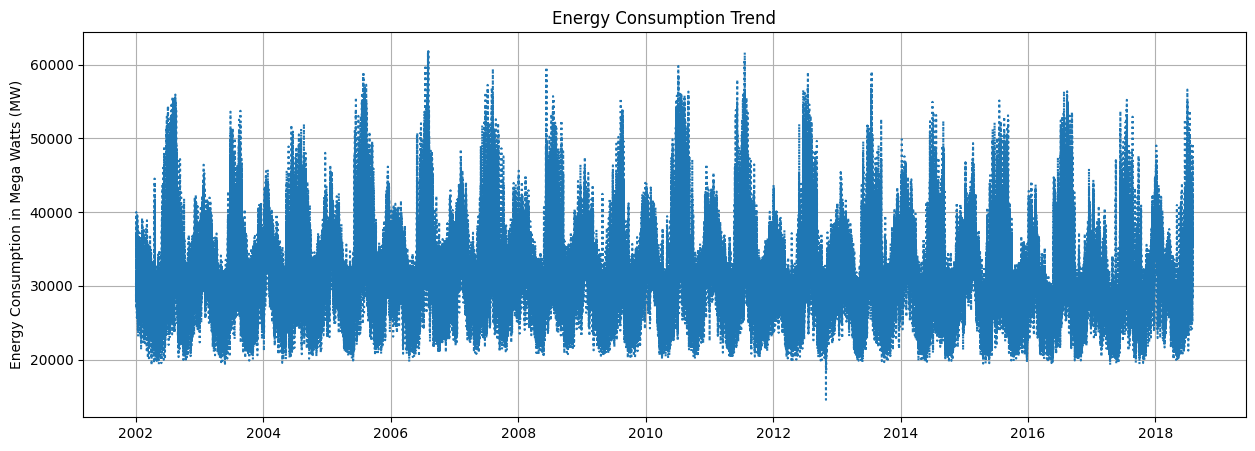

In [382]:
fig, ax = plt.subplots(figsize=(15,5))
ax.plot(df, linestyle="dotted")
plt.ylabel("Energy Consumption in Mega Watts (MW)")
plt.title("Energy Consumption Trend")
plt.grid();


    1. Outlier Analysis and removal

In [383]:
mean = df["PJME_MW"].mean()
std = df["PJME_MW"].std()


In [384]:
print("+1 Standard Deviation Value:", std)
print("+2 Standard Deviation Value:", std*2)
print("+3 Standard Deviation Value:", std*3)

+1 Standard Deviation Value: 6464.0121664127355
+2 Standard Deviation Value: 12928.024332825471
+3 Standard Deviation Value: 19392.036499238206


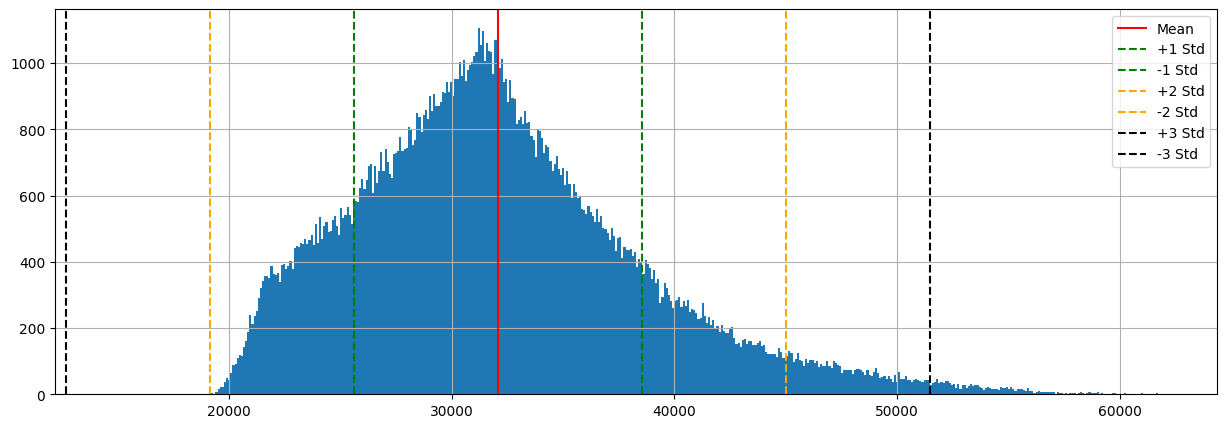

In [385]:
fig, ax = plt.subplots(figsize=(15,5))

ax.hist(df["PJME_MW"], bins=500)

ax.axvline(mean, color="red", label="Mean")
ax.axvline(mean + std, color="green", linestyle="--", label="+1 Std")
ax.axvline(mean - std, color="green", linestyle="--", label="-1 Std")
ax.axvline(mean + 2*std, color="orange", linestyle="--", label="+2 Std")
ax.axvline(mean - 2*std, color="orange", linestyle="--", label="-2 Std")
ax.axvline(mean + 3*std, color="black", linestyle="--", label="+3 Std")
ax.axvline(mean - 3*std, color="black", linestyle="--", label="-3 Std")
plt.legend()
plt.grid()

<Axes: xlabel='Datetime'>

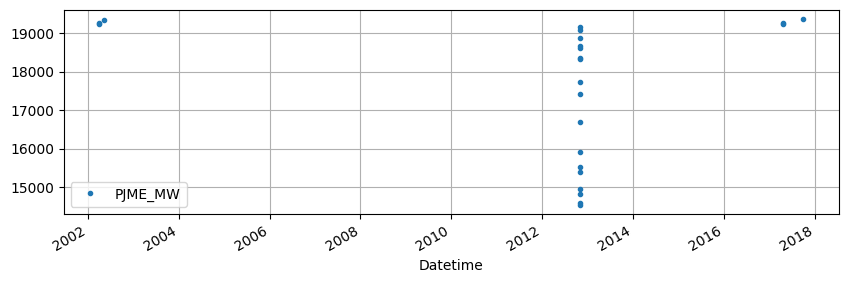

In [386]:
# df.loc[df["PJME_MW"] < 19_000].plot(figsize=(15,5), style=".", grid=True)  This works just the same
df.query(f"PJME_MW < {3* std}").plot(figsize=(10,3),style=".", grid=True)

In [387]:
train = df.loc[df.index<"01-01-2015"]
test = df.loc[df.index>="01-01-2015"]

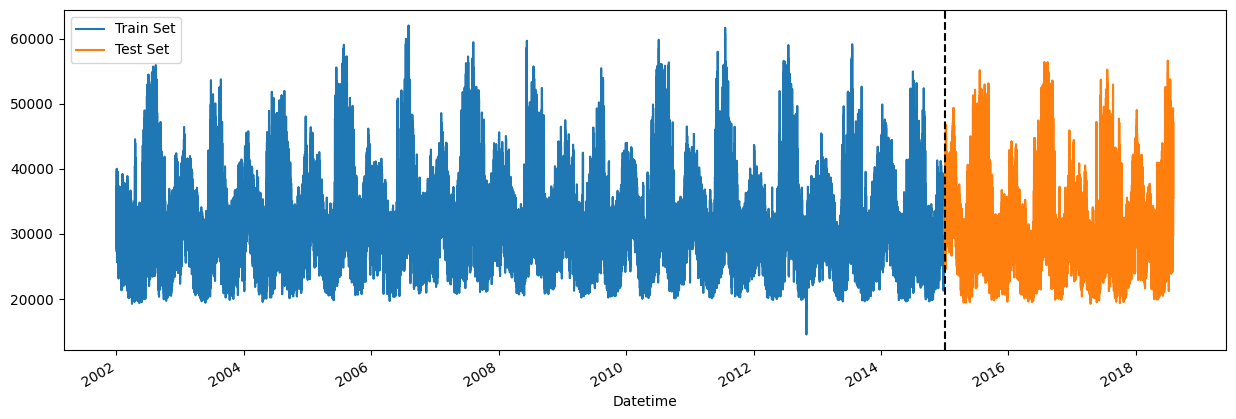

In [388]:
fig, ax = plt.subplots(figsize=(15,5))
train.plot(ax=ax)
test.plot(ax=ax)
ax.axvline("2015-01-01", color="black", linestyle="--")
ax.legend(["Train Set", "Test Set"])
plt.show()

    Time Series Cross validation

In [389]:
# last_year = df.index.year.unique().sort_values(ascending=False)[1] # we are using second last year since last year is 2018 and it does not have full complete year data
# len(df[df.index.year==last_year])

# Or Simply we can do this
# df.loc[df.index.year == df.index.year.unique()[-1]] 

In [390]:
24*365*1

8760

In [391]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1) # This is a generator
df = df.sort_index()
print(type(tss))

<class 'sklearn.model_selection._split.TimeSeriesSplit'>


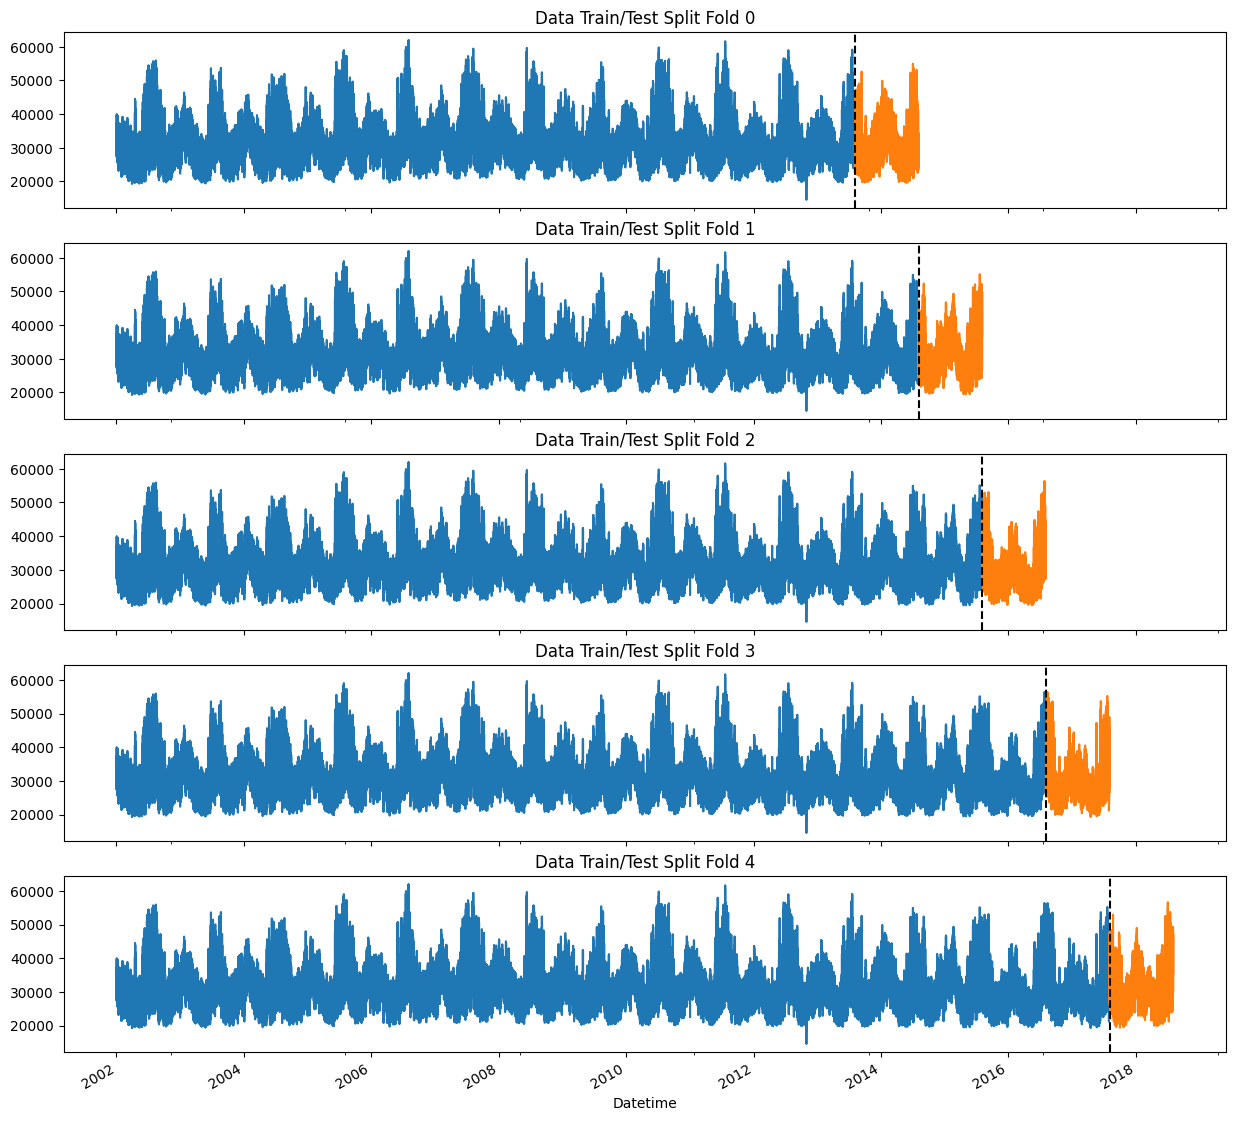

In [392]:
fig, axs = plt.subplots(5, 1, figsize=(15, 15), sharex=True)

fold = 0
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]
    train['PJME_MW'].plot(ax=axs[fold],
                          label='Training Set',
                          title=f'Data Train/Test Split Fold {fold}')
    test['PJME_MW'].plot(ax=axs[fold],
                         label='Test Set')
    axs[fold].axvline(test.index.min(), color='black', ls='--')
    fold += 1
plt.show()

<p style="color: yellow; font-size:20px">What is Forecast horizon?</p>

#### Feature Engineering

In [393]:
def create_features(df):
    """Create time series features based on time series index."""
    
    df = df.copy()
    df["hour"] = df.index.hour
    df["dayofweek"] = df.index.day_of_week
    df["quarter"] = df.index.quarter
    df["month"] = df.index.month
    df["year"] = df.index.year
    df["dayofyear"] = df.index.dayofyear
    return df


    Lag Features

In [394]:
def add_lags(df):

    df=df.copy()
    df = df[~df.index.duplicated(keep='first')]  # or 'last', or aggregate
    df["lag1"]  = df["PJME_MW"].shift(freq="364D")
    df["lag2"]  = df["PJME_MW"].shift(freq="728D")
    df["lag3"]  = df["PJME_MW"].shift(freq="1092D")

    return df

In [395]:
df = create_features(df)
df = add_lags(df)
df

,PJME_MW,hour,dayofweek,quarter,month,year,dayofyear,lag1,lag2,lag3
Datetime,,,,,,,,,,
2002-01-01 01:00:00,30393.0,1,1,1,1,2002,1,NaN,NaN,NaN
2002-01-01 02:00:00,29265.0,2,1,1,1,2002,1,NaN,NaN,NaN
2002-01-01 03:00:00,28357.0,3,1,1,1,2002,1,NaN,NaN,NaN
2002-01-01 04:00:00,27899.0,4,1,1,1,2002,1,NaN,NaN,NaN
2002-01-01 05:00:00,28057.0,5,1,1,1,2002,1,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2018-08-02 20:00:00,44057.0,20,3,3,8,2018,214,42256.0,41485.0,38804.0
2018-08-02 21:00:00,43256.0,21,3,3,8,2018,214,41210.0,40249.0,38748.0
2018-08-02 22:00:00,41552.0,22,3,3,8,2018,214,39525.0,38698.0,37330.0


#### Model Training

In [396]:
tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1) # This is a generator
df = df.sort_index()
print(type(tss))

<class 'sklearn.model_selection._split.TimeSeriesSplit'>


In [397]:
import time

tss = TimeSeriesSplit(n_splits=5, test_size=24*365*1, gap=24)
df = df.sort_index()


fold = 0
preds = []
scores = []
start_time = time.time()
for train_idx, val_idx in tss.split(df):
    train = df.iloc[train_idx]
    test = df.iloc[val_idx]

    train = create_features(train)
    test = create_features(test)

    FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month','year',
                'lag1','lag2','lag3']
    TARGET = 'PJME_MW'

    X_train = train[FEATURES]
    y_train = train[TARGET]

    X_test = test[FEATURES]
    y_test = test[TARGET]

    reg = xgb.XGBRegressor(base_score=0.5, booster='gbtree',    
                           n_estimators=1000,
                           early_stopping_rounds=50,
                           objective='reg:squarederror',
                           max_depth=3,
                           learning_rate=0.01, device="cuda")
    reg.fit(X_train, y_train,
            eval_set=[(X_train, y_train), (X_test, y_test)],
            verbose=100)

    y_pred = reg.predict(X_test)
    preds.append(y_pred)
    score = np.sqrt(mean_squared_error(y_test, y_pred))
    scores.append(score)

end_time = time.time()
print(end_time-start_time)

[0]	validation_0-rmse:32730.42678	validation_1-rmse:31957.05942
[100]	validation_0-rmse:12532.42744	validation_1-rmse:11911.21763
[200]	validation_0-rmse:5747.38497	validation_1-rmse:5360.65028
[300]	validation_0-rmse:3870.23059	validation_1-rmse:3899.60489
[400]	validation_0-rmse:3436.15917	validation_1-rmse:3760.09285
[442]	validation_0-rmse:3370.18809	validation_1-rmse:3762.93734
[0]	validation_0-rmse:32670.58126	validation_1-rmse:32136.60977
[100]	validation_0-rmse:12513.82527	validation_1-rmse:12224.07610
[200]	validation_0-rmse:5756.97781	validation_1-rmse:5644.02579
[300]	validation_0-rmse:3908.60764	validation_1-rmse:3925.58811
[400]	validation_0-rmse:3480.49944	validation_1-rmse:3596.76659
[500]	validation_0-rmse:3355.25423	validation_1-rmse:3525.20216
[600]	validation_0-rmse:3299.47982	validation_1-rmse:3488.67479
[700]	validation_0-rmse:3260.19316	validation_1-rmse:3467.48851
[800]	validation_0-rmse:3224.28473	validation_1-rmse:3442.91036
[900]	validation_0-rmse:3196.11633	v

In [398]:
print(f'Score across folds {np.mean(scores):0.4f}')
print(f'Fold scores:{scores}')

Score across folds 3753.7305
Fold scores:[np.float64(3759.7674356108796), np.float64(3415.7910168984954), np.float64(3475.7483503980625), np.float64(4117.598375919026), np.float64(3999.7475090232138)]


#### 4. Predicting the Future
Retraining on all data
To Predict the future we need an emtpy dataframe for future date ranges.
Run those dates through our feature creation code + lag creation

In [399]:
# Retrain on all data
df = create_features(df)

FEATURES = ['dayofyear', 'hour', 'dayofweek', 'quarter', 'month', 'year',
            'lag1','lag2','lag3']
TARGET = 'PJME_MW'

X_all = df[FEATURES]
y_all = df[TARGET]

reg = xgb.XGBRegressor(base_score=0.5,
                       booster='gbtree',    
                       n_estimators=500,
                       objective='reg:linear',
                       max_depth=3,
                       learning_rate=0.01)
reg.fit(X_all, y_all,
        eval_set=[(X_all, y_all)],
        verbose=100)

[0]	validation_0-rmse:32402.91229


d:\#Data Science\Time_series_analysis\time_series_analysis\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:59:59] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\objective\regression_obj.cu:277: reg:linear is now deprecated in favor of reg:squarederror.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-rmse:12426.85074
[200]	validation_0-rmse:5753.48504
[300]	validation_0-rmse:3971.84887
[400]	validation_0-rmse:3571.24315
[499]	validation_0-rmse:3457.48050


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:linear'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",0.5
,booster,'gbtree'
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [400]:
df.index.max()


Timestamp('2018-08-03 00:00:00')

In [401]:
# Create future dataframe
future = pd.date_range('2018-08-03','2019-08-01', freq='1h')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
df['isFuture'] = False
df_and_future = pd.concat([df, future_df])
df_and_future = create_features(df_and_future)
df_and_future = add_lags(df_and_future)

In [402]:
future_w_features = df_and_future.query('isFuture').copy()


In [404]:
future_w_features['pred'] = reg.predict(future_w_features[FEATURES])


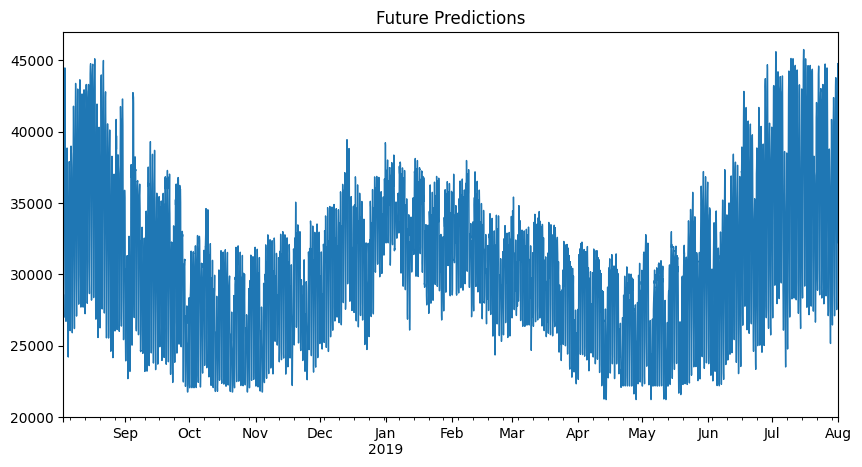

In [405]:
future_w_features['pred'].plot(figsize=(10, 5),
                               ms=1,
                               lw=1,
                               title='Future Predictions')
plt.show()

In [406]:
# Save model
reg.save_model('model.json')

<Axes: title={'center': 'Future Predictions'}>

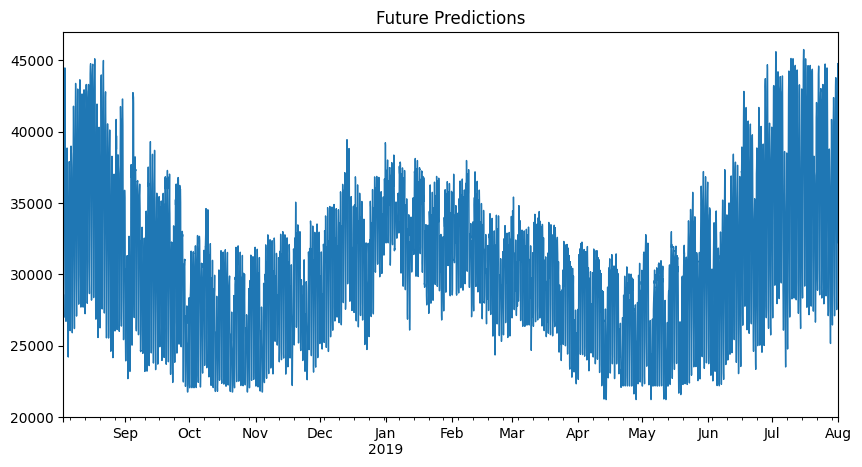

In [407]:
reg_new = xgb.XGBRegressor()
reg_new.load_model('model.json')
future_w_features['pred'] = reg_new.predict(future_w_features[FEATURES])
future_w_features['pred'].plot(figsize=(10, 5),
                               ms=1, lw=1,
                               title='Future Predictions')